# Mutational Signature Simulation & Alpha Optimisation

## What this notebook does

We model colorectal tumour mutation profiles under two scenarios:

P_normal   = 0.4*SBS1 + 0.4*SBS5 + 0.2*SBS18

P_infected(alpha) = alpha * SBS88 + (1 - alpha) * P_normal

alpha is the fraction of a tumour's mutations caused by colibactin (pks+ E. coli).

**Part 1 (original):** Sensitivity simulations: at what injection level can we reliably detect SBS88 using cosine similarity and KL divergence, and how do Gaussian / Beta / LogNormal assumptions about alpha compare?

**Part 2 (new):** Alpha optimisation. for each distribution model, find the `mean_a` (the expected colibactin exposure level across the population) that makes simulated spectra look most like the observed data. This `mean_a` is the scientifically meaningful optimal alpha. We then use it to compute P(APC c.835-8A>G | alpha), the sensitivity curve linking colibactin dose to the probability of the cancer-initiating APC mutation.


Original Simulation Code (unchanged)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy import stats
from numpy.linalg import norm

In [6]:
df = pd.read_csv("Context_SBS_2.txt", sep=",")
print("\033[4m Check summary statistics: \033[0m\n", df.describe(), "\n")
print("\033[4m Check data consistency: \033[0m\n", np.sum(df, 0))
df.head()
## Note that the Contect labels are not in the same order as in the Webpage

 Check summary statistics: 
        SBS88_GRCh38   SBS1_GRCh38  SBS5_GRCh38  SBS18_GRCh38
count  9.600000e+01  9.600000e+01    96.000000     96.000000
mean   1.041667e-02  1.041667e-02     0.010417      0.010417
std    2.636269e-02  4.859203e-02     0.008391      0.020818
min    1.000000e-18  2.165410e-16     0.001510      0.000037
25%    1.000000e-18  6.260207e-05     0.004819      0.001901
50%    1.727785e-03  2.524201e-04     0.007623      0.003197
75%    6.339078e-03  1.336084e-03     0.013547      0.008433
max    1.689750e-01  3.706239e-01     0.046191      0.122080 

 Check data consistency: 
 Context         A[C>A]AA[C>A]CA[C>A]GA[C>A]TA[C>G]AA[C>G]CA[C>...
SBS88_GRCh38                                                  1.0
SBS1_GRCh38                                                   1.0
SBS5_GRCh38                                                   1.0
SBS18_GRCh38                                                  1.0
dtype: object


,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534
1,A[C>A]C,1.000000e-18,0.002220,0.009438,0.015810
2,A[C>A]G,1.000000e-18,0.000180,0.001850,0.002432
3,A[C>A]T,1.737757e-03,0.001265,0.006609,0.021414
4,A[C>G]A,1.000000e-18,0.001839,0.010098,0.001731


In [7]:
# Adding the normal colon, with weights for SBS1, SBS5 and SBS18, 0.4, 0.4, 0.2
df["Normal_colon"] = 0.4*df["SBS1_GRCh38"] + 0.4*df["SBS5_GRCh38"] + 0.2*df["SBS18_GRCh38"]
print("Sum of all elements should be 1: ", sum(df["Normal_colon"]))
df.head()

Sum of all elements should be 1:  0.9999999999999972


,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38,Normal_colon
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456
1,A[C>A]C,1.000000e-18,0.002220,0.009438,0.015810,0.007825
2,A[C>A]G,1.000000e-18,0.000180,0.001850,0.002432,0.001298
3,A[C>A]T,1.737757e-03,0.001265,0.006609,0.021414,0.007432
4,A[C>G]A,1.000000e-18,0.001839,0.010098,0.001731,0.005121


In [8]:
# Reordering the Context column so it matches the one in the web
# which is ordered according to alphabetical order of the single
# base substitution first
def basis_change_first(a):
    return a[1:-1]+a[0]+a[-1]

df["context_ordered"] = df["Context"].map(basis_change_first)
df.head()

,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38,Normal_colon,context_ordered
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,[C>A]AA
1,A[C>A]C,1.000000e-18,0.002220,0.009438,0.015810,0.007825,[C>A]AC
2,A[C>A]G,1.000000e-18,0.000180,0.001850,0.002432,0.001298,[C>A]AG
3,A[C>A]T,1.737757e-03,0.001265,0.006609,0.021414,0.007432,[C>A]AT
4,A[C>G]A,1.000000e-18,0.001839,0.010098,0.001731,0.005121,[C>G]AA


In [9]:
final_df = df.sort_values(by=["context_ordered"]).reset_index(drop=True).drop("context_ordered", axis=1)
final_df.head()

,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38,Normal_colon
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456
1,A[C>A]C,1.000000e-18,0.002220,0.009438,0.015810,0.007825
2,A[C>A]G,1.000000e-18,0.000180,0.001850,0.002432,0.001298
3,A[C>A]T,1.737757e-03,0.001265,0.006609,0.021414,0.007432
4,C[C>A]A,1.000000e-18,0.000305,0.007429,0.074049,0.017903


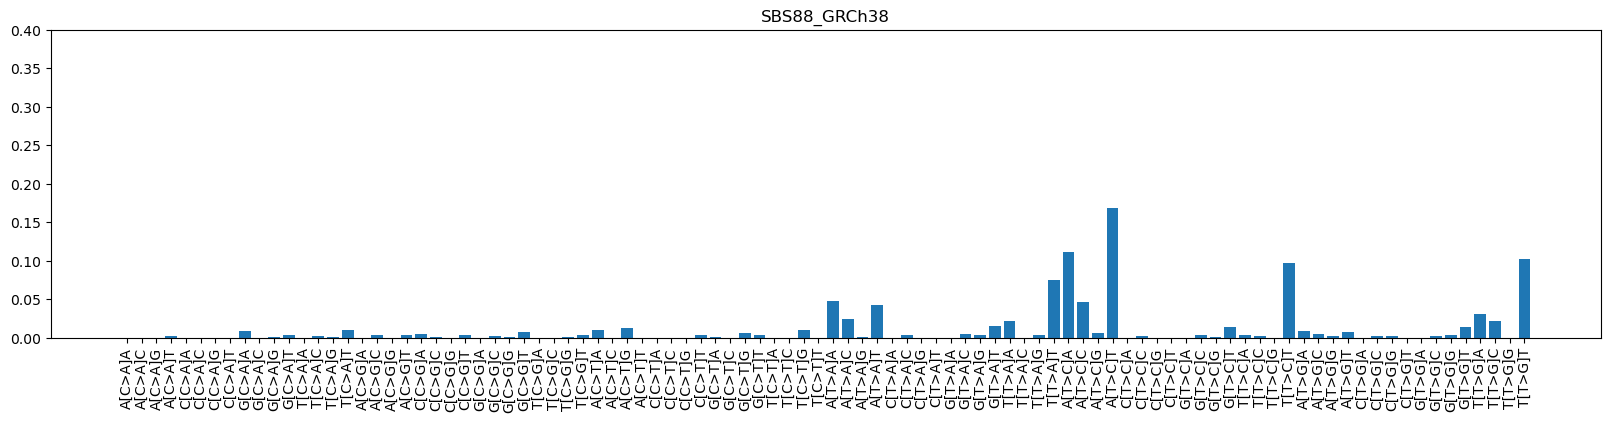

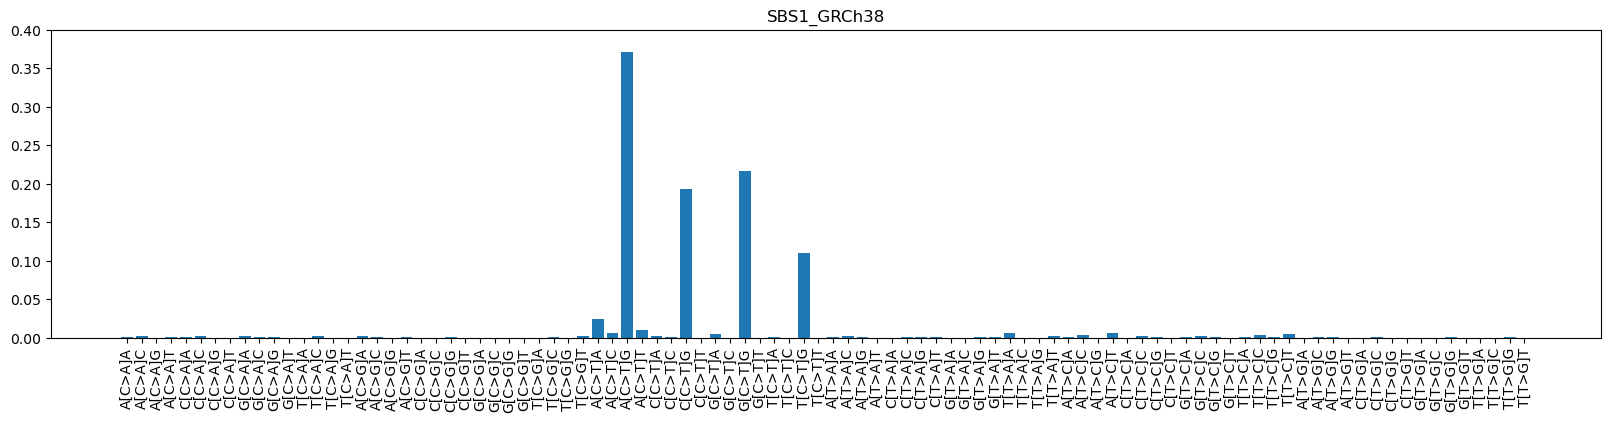

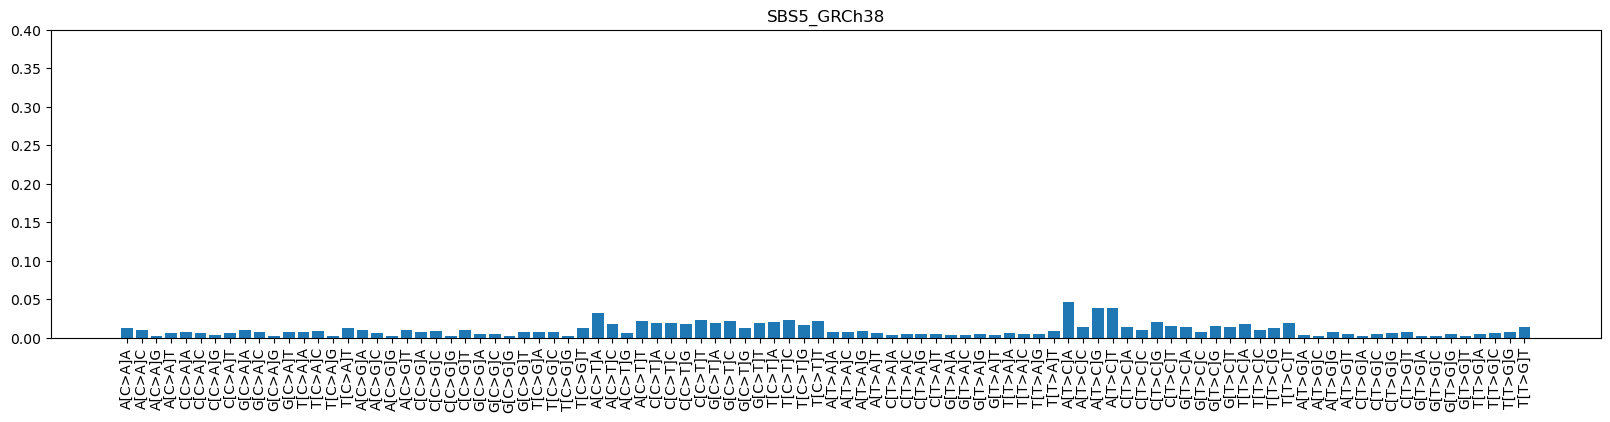

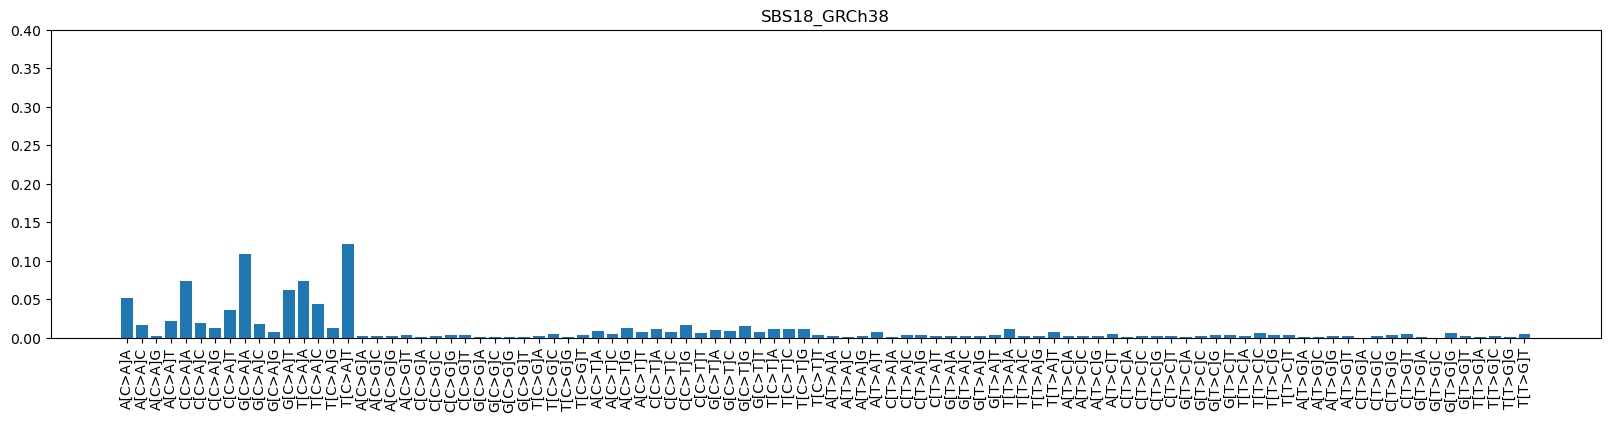

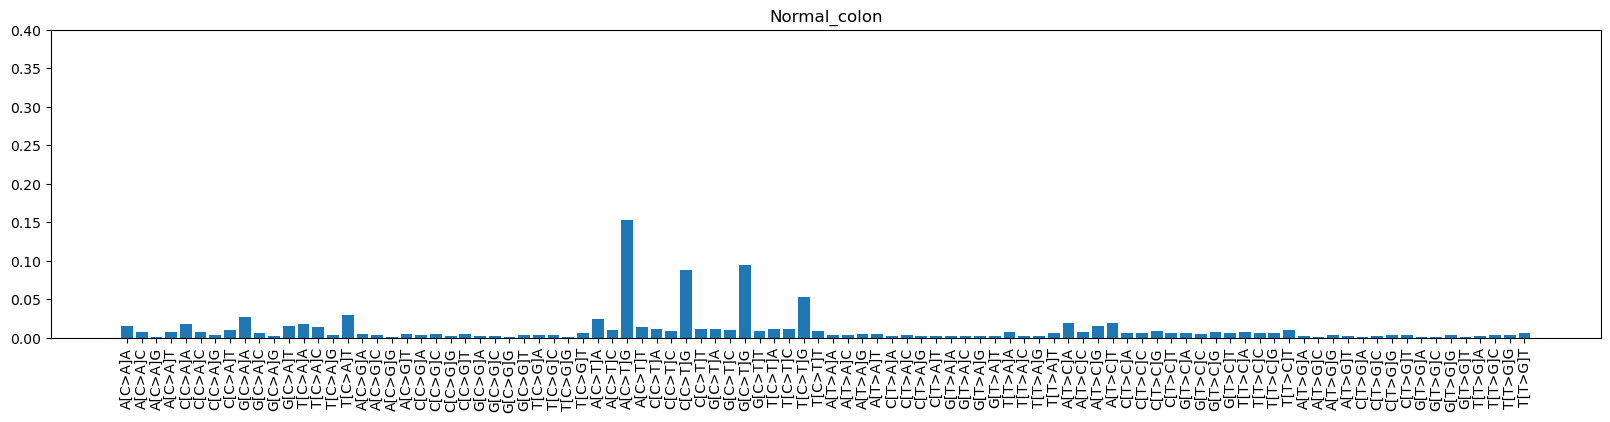

In [10]:
for col in final_df.columns[1:]:
    fig = plt.figure(figsize=(20, 4))
    ax = fig.add_subplot()
    ax.bar(final_df["Context"], final_df[col])
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(top=0.4)
    plt.title(col)
    plt.show()

In [11]:
def vis_data(data, x_axis, labels=["Test"], title="Test", alpha=1):
    fig = plt.figure(figsize=(20, 4))
    ax = fig.add_subplot()
    for i in range(len(data)):
        ax.bar(x_axis, data[i], label=labels[i], alpha=alpha)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(top=0.4)
    plt.legend()
    plt.title(title)
    plt.show()

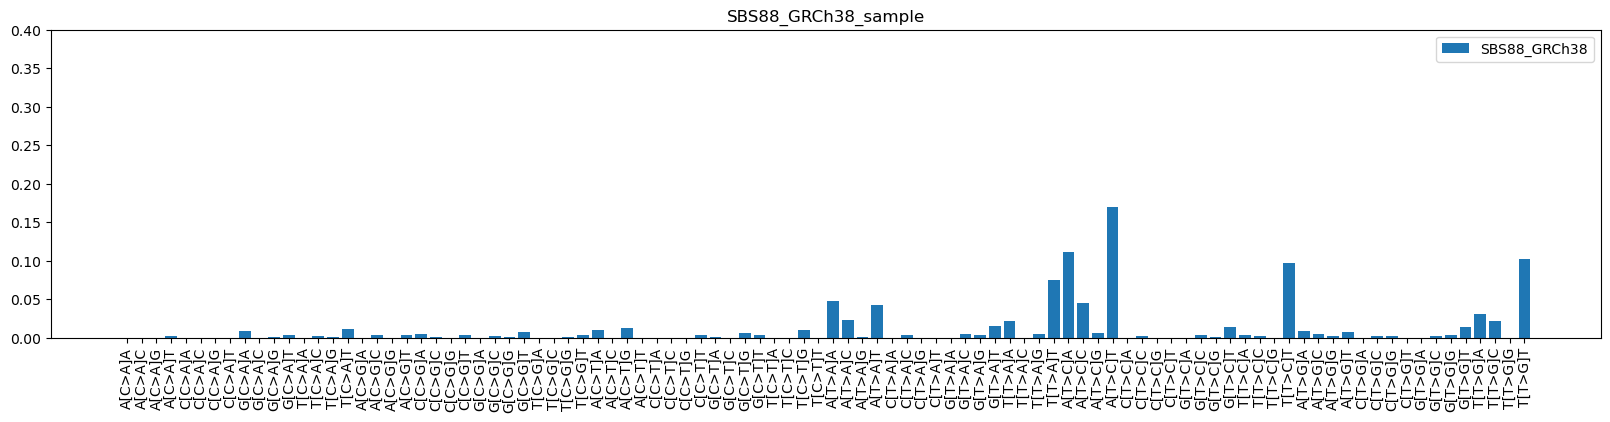

In [12]:
# We want a function that simulates the mutational signature of a weighted
# combination of SBS88_GRCh38 and the Normal-colon
# something like a*SBS88 + (1 - a)*Normal-colon

# test
samples = random.choices(range(96), final_df["SBS88_GRCh38"], k=10**6)
counts_scaled = np.bincount(samples, minlength=96)/len(samples)

vis_data([counts_scaled], final_df["Context"], ["SBS88_GRCh38"], "SBS88_GRCh38_sample")

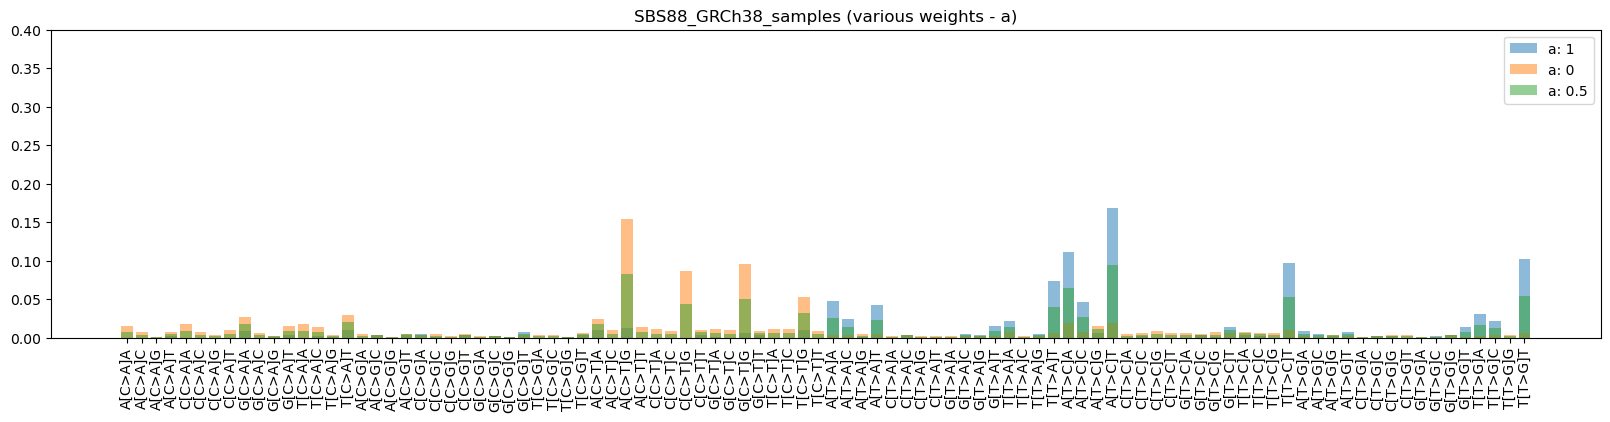

In [13]:
# parametrized function
def sample_mutational_signature(df, distrib, a=1, k=10**6):
    '''
    Args:
        df: Dataframe with the data 
        distrib: Target distribution to sample from (apart from the Normal-colon distribution)
        a: Weight of the target distribution (1-a will be the weight of the Normal-colon distribution)
        k: Number of samples
    '''
    final_distrib = a*final_df[distrib] + (1-a)*final_df["Normal_colon"]
    samples = random.choices(range(96), final_distrib, k=k)
    counts_scaled = np.bincount(samples, minlength=96)/len(samples)
    return counts_scaled

# test
a_1, a_2, a_3 = 1, 0, 0.5
test_1 = sample_mutational_signature(final_df, "SBS88_GRCh38", a_1)
test_2 = sample_mutational_signature(final_df, "SBS88_GRCh38", a_2)
test_3 = sample_mutational_signature(final_df, "SBS88_GRCh38", a_3)
vis_data([test_1, test_2, test_3], final_df["Context"], [f"a: {a_1}", f"a: {a_2}", f"a: {a_3}"],
          f"SBS88_GRCh38_samples (various weights - a)", 0.5)

In [14]:
COLOURS = {
    "Gaussian": "#2166AC",
    "Beta":"#D6604D",
    "LogNormal":"#4DAC26",}

MUT_TYPE_COLOURS = {
    "C>A": "#03BCEE",
    "C>G": "#010101",
    "C>T": "#E22926",
    "T>A": "#CAC9C9",
    "T>C": "#A1CE63",
    "T>G": "#ECC6C5"
}

def get_mut_type(context):
    'Extract substitution type'
    return context[2:5]

def context_colours(contexts):
    'Return COSMIC colour list for a list of 96 trinucleotide contexts'
    return [MUT_TYPE_COLOURS[get_mut_type(c)] for c in contexts]

contexts = list(final_df['Context'])
colours = context_colours(contexts)
print('Imports and colours all ok :)')

Imports and colours all ok :)


In [15]:
#gaussian
def simulate_gaussian(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    '''
    mean_a: target proportion of SSBS
    std fixed at 0.1 of mean (same as paper)
    '''
    results=[]
    for __ in range(n_trials):
        a=np.random.normal(loc=mean_a, scale=0.1*mean_a)
        a=np.clip(a,0,1)
        spectrum=sample_mutational_signature(df, distrib, a, k=n_mutations)
        results.append(spectrum)
    return np.array(results) # shape (n_trials,96)

#beta (naturally bonded between 0 and 1)
def simulate_beta(df, distrib, mean_a, variance=None, n_trials=200, n_mutations=5000):
    '''
    Parameterised by mean and variance.
    Default variance = (0.1 * mean_a)^2 to match Gaussian spread.
    '''
    if variance is None:
        variance = (0.1 * mean_a) ** 2

    max_variance = mean_a * (1 - mean_a) * 0.99
    variance = min(variance, max_variance)
    
    alpha = mean_a * (mean_a * (1 - mean_a) / variance - 1)
    beta  = (1 - mean_a) * (mean_a * (1 - mean_a) / variance - 1)
    
    results = []
    for _ in range(n_trials):
        a = np.random.beta(alpha, beta)
        spectrum = sample_mutational_signature(df, distrib, a, k=n_mutations)
        results.append(spectrum)
    return np.array(results)

#log-normal
def simulate_lognormal(df, distrib, mean_a, n_trials=200, n_mutations=5000):
    '''
    Log-normal parameterised so the median equals mean_a.
    sigma fixed at 0.3 (moderate right skew).
    '''
    sigma = 0.3
    mu = np.log(mean_a)
    
    results = []
    for _ in range(n_trials):
        a = np.random.lognormal(mu, sigma)
        a = np.clip(a, 0, 1)
        spectrum = sample_mutational_signature(df, distrib, a, k=n_mutations)
        results.append(spectrum)
    return np.array(results)

In [16]:
tcga = pd.read_csv("tcga_data.csv", sep="\t", low_memory=False)
sample_counts = tcga.groupby("Sample ID")["# Mut in Sample"].first().dropna()
sample_counts = sample_counts[sample_counts > 50].values

In [17]:
# Run simulations 
n_mutations = int(np.median(sample_counts))
n_trials = 200

gauss_results = simulate_gaussian(final_df, "SBS88_GRCh38", mean_a=0.05, 
                                   n_trials=n_trials, n_mutations=n_mutations)

beta_results  = simulate_beta(final_df, "SBS88_GRCh38", mean_a=0.05, 
                               n_trials=n_trials, n_mutations=n_mutations)

logn_results  = simulate_lognormal(final_df, "SBS88_GRCh38", mean_a=0.05, 
                                    n_trials=n_trials, n_mutations=n_mutations)

print(f"gauss_results shape: {gauss_results.shape}")   # should be (200, 96)
print(f"beta_results shape:  {beta_results.shape}")
print(f"logn_results shape:  {logn_results.shape}")

gauss_results shape: (200, 96)
beta_results shape:  (200, 96)
logn_results shape:  (200, 96)


In [18]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

true_sbs88 = final_df["SBS88_GRCh38"].values

for label, results in [("Gaussian", gauss_results), 
                        ("Beta", beta_results), 
                        ("LogNormal", logn_results)]:
    sims = [cosine_similarity(r, true_sbs88) for r in results]
    print(f"{label}: mean cosine = {np.mean(sims):.4f}, std = {np.std(sims):.4f}")

Gaussian: mean cosine = 0.2556, std = 0.0579
Beta: mean cosine = 0.2531, std = 0.0568
LogNormal: mean cosine = 0.2547, std = 0.0641


In [19]:
injection_levels = [0.01, 0.05, 0.10, 0.15, 0.20]
n_trials = 200

# Pull mutation counts from TCGA
tcga = pd.read_csv("tcga_data.csv", sep="\t", low_memory=False)
sample_counts = tcga.groupby("Sample ID")["# Mut in Sample"].first().dropna()
sample_counts = sample_counts[sample_counts > 50].values

true_sbs88 = final_df["SBS88_GRCh38"].values

results = {"Gaussian": {}, "Beta": {}, "LogNormal": {}}

for level in injection_levels:
    n_muts = int(np.random.choice(sample_counts))
    results["Gaussian"][level]  = simulate_gaussian(final_df, "SBS88_GRCh38", level, n_trials, n_muts)
    results["Beta"][level] = simulate_beta(final_df, "SBS88_GRCh38", level, n_trials, n_muts)
    results["LogNormal"][level] = simulate_lognormal(final_df, "SBS88_GRCh38", level, n_trials, n_muts)

In [20]:
cosine_results = {dist: {} for dist in results}

for dist, levels in results.items():
    for level, spectra in levels.items():
        sims = [cosine_similarity(s, true_sbs88) for s in spectra]
        cosine_results[dist][level] = sims

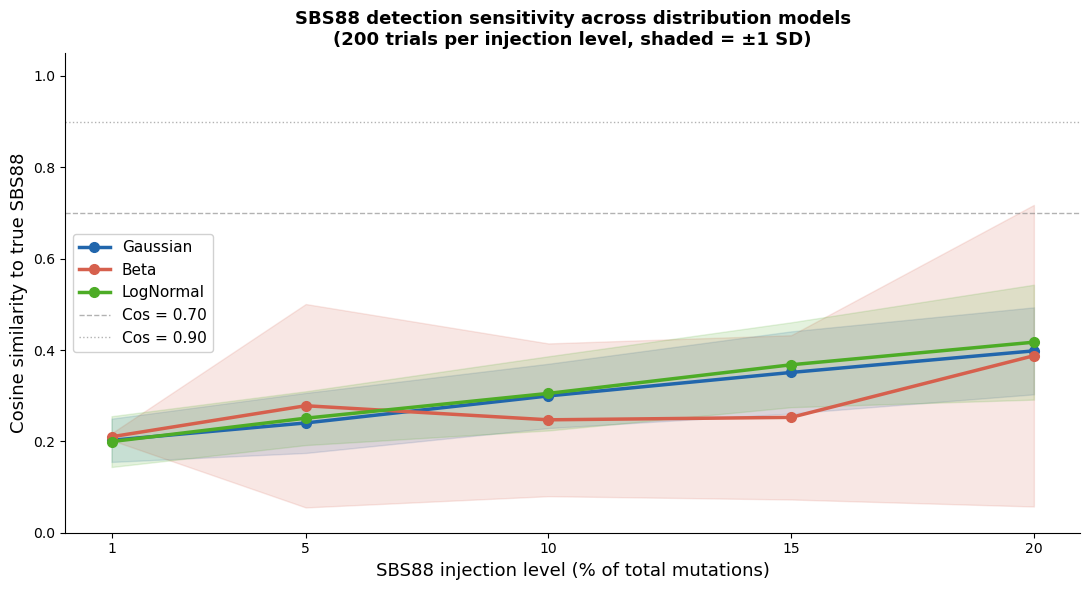

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

for dist, levels in cosine_results.items():
    means = [np.mean(levels[l]) for l in injection_levels]
    stds  = [np.std(levels[l])  for l in injection_levels]
    pcts  = [l * 100            for l in injection_levels]
    ax.plot(pcts, means, marker='o', linewidth=2.5, markersize=7,
            label=dist, color=COLOURS[dist])
    ax.fill_between(pcts,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.15, color=COLOURS[dist])

ax.axhline(0.7, color='grey', linestyle='--', linewidth=1.0, alpha=0.6, label='Cos = 0.70')
ax.axhline(0.9, color='grey', linestyle=':',  linewidth=1.0, alpha=0.6, label='Cos = 0.90')
ax.set_xlabel('SBS88 injection level (% of total mutations)', fontsize=13)
ax.set_ylabel('Cosine similarity to true SBS88', fontsize=13)
ax.set_title('SBS88 detection sensitivity across distribution models\n'
             '(200 trials per injection level, shaded = ±1 SD)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticks([l * 100 for l in injection_levels])
ax.legend(framealpha=0.9, fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('sensitivity_curves_all_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

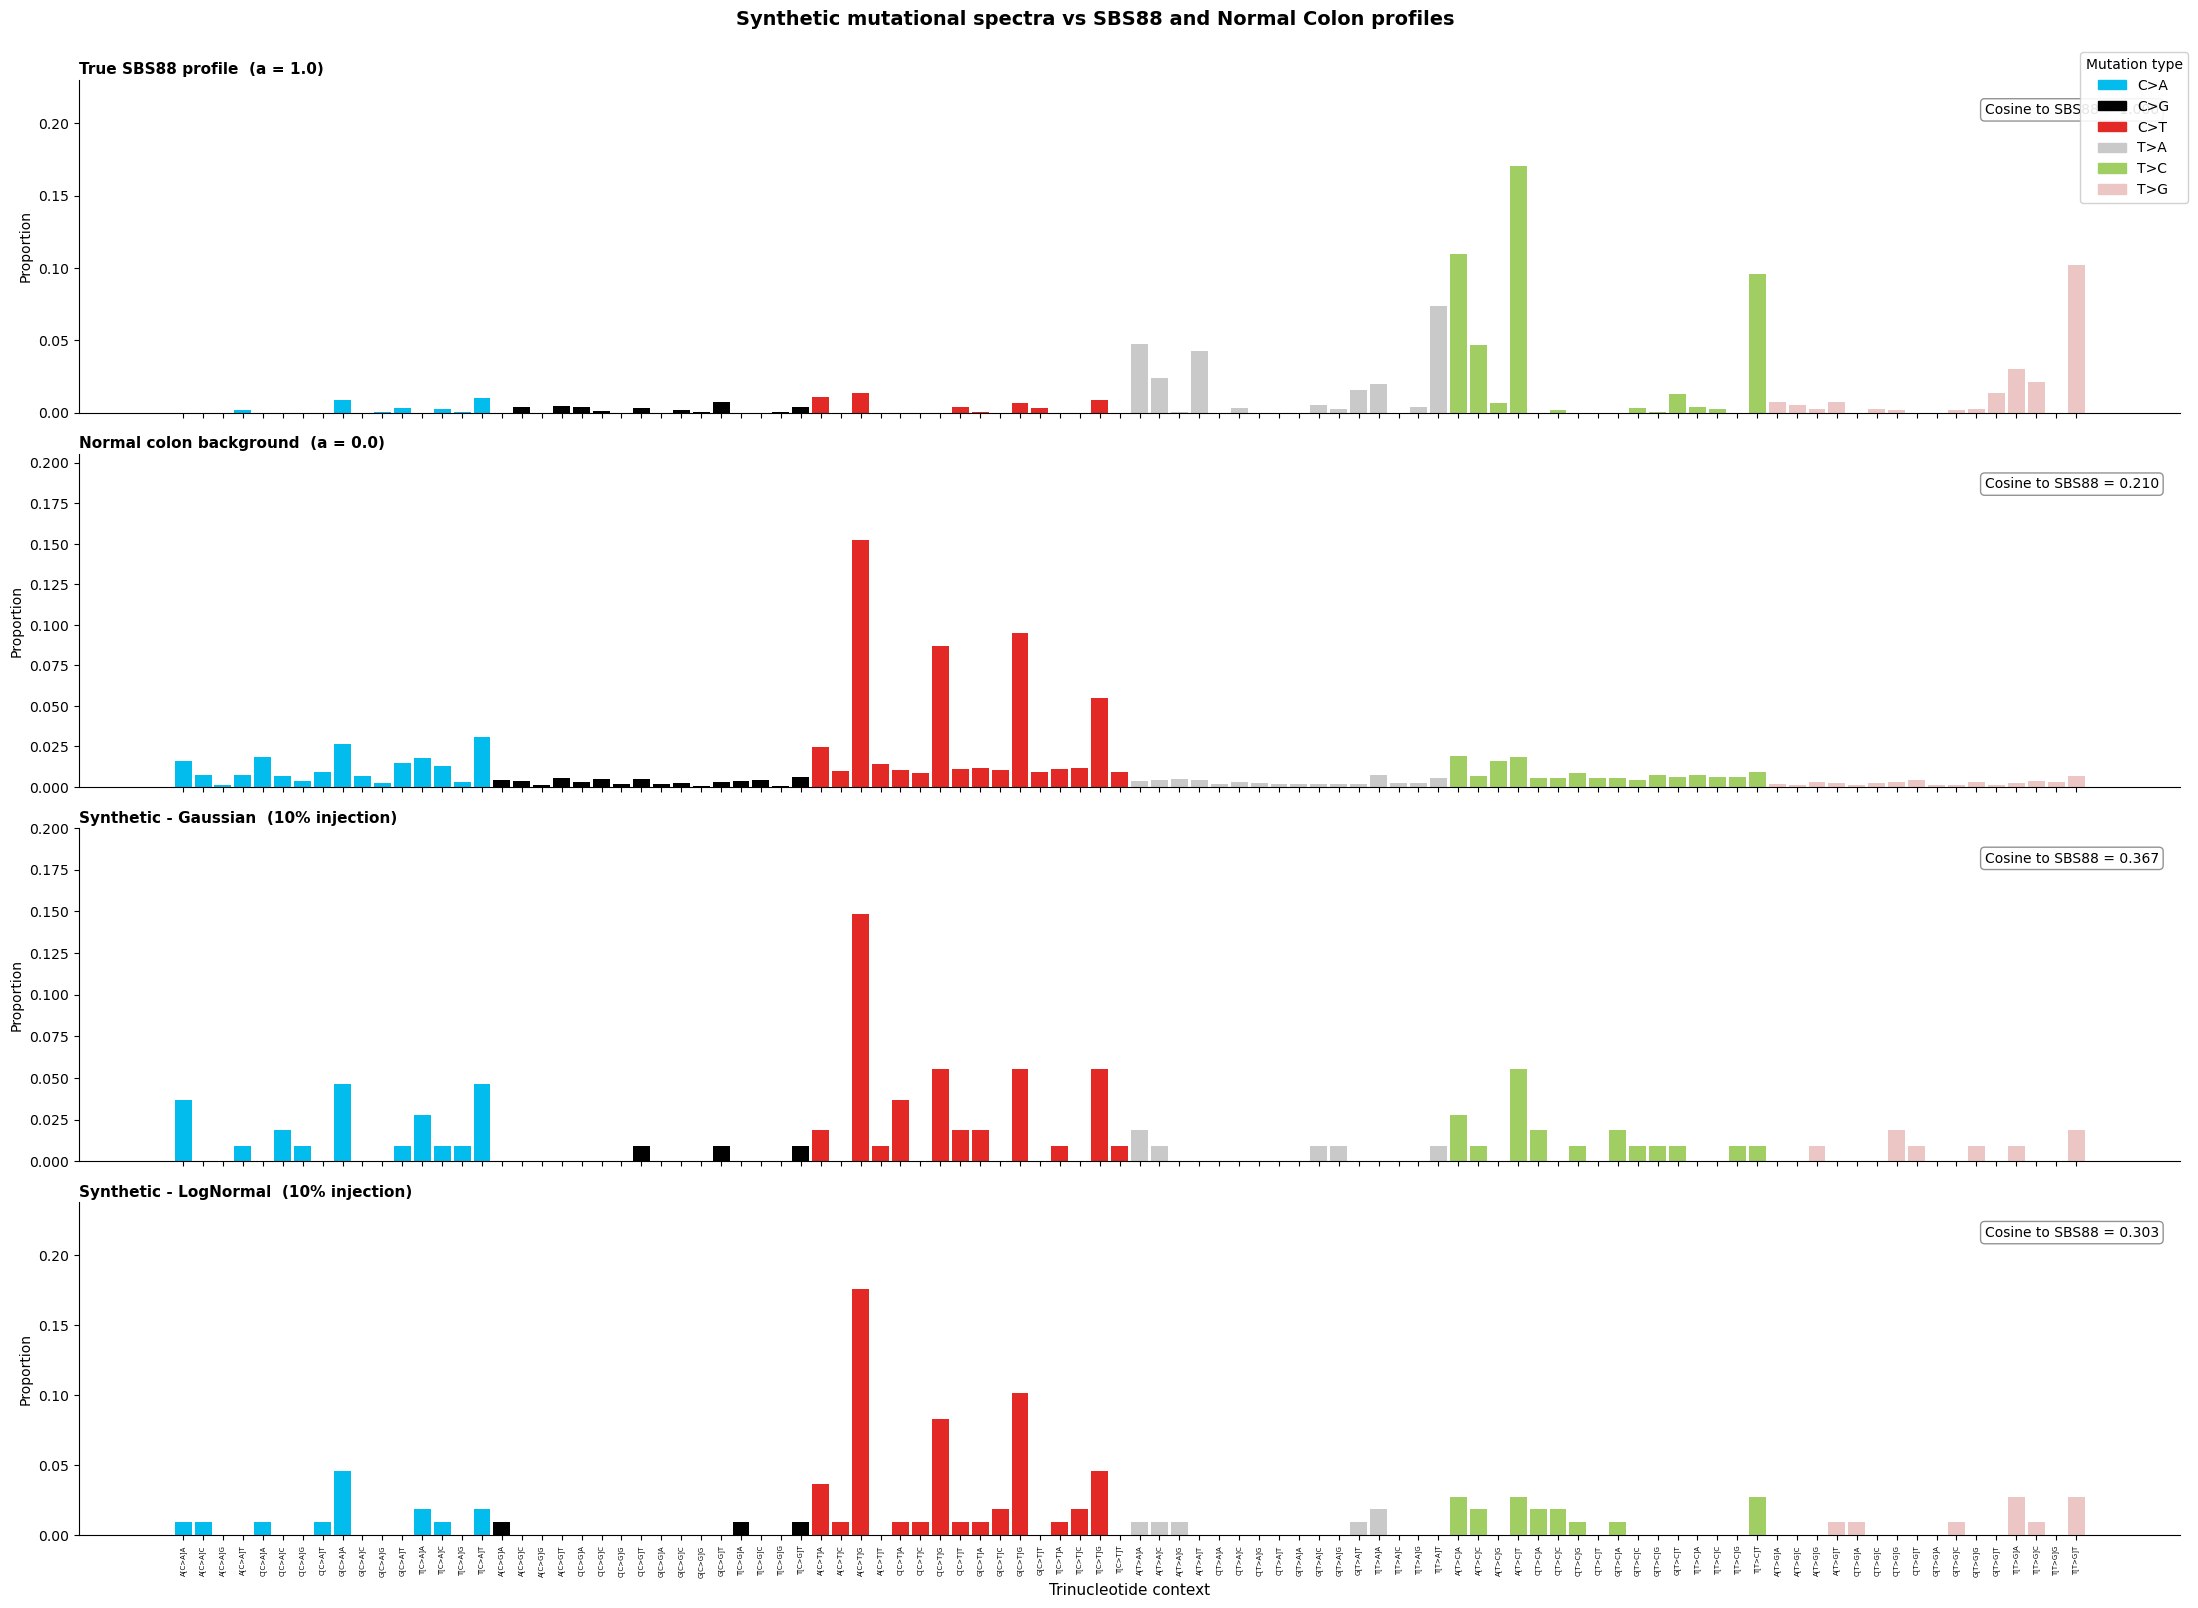

In [22]:
import matplotlib.patches as mpatches

n_muts_median = int(np.median(sample_counts))

spec_pure_sbs88  = sample_mutational_signature(final_df, 'SBS88_GRCh38', a=1.0, k=50000)
spec_background  = sample_mutational_signature(final_df, 'SBS88_GRCh38', a=0.0, k=50000)
spec_gauss_10    = simulate_gaussian(final_df, 'SBS88_GRCh38', 0.10, n_trials=1, n_mutations=n_muts_median)[0]
spec_lognorm_10  = simulate_lognormal(final_df, 'SBS88_GRCh38', 0.10, n_trials=1, n_mutations=n_muts_median)[0]

spectra_to_plot = [
    (spec_pure_sbs88, 'True SBS88 profile  (a = 1.0)'),
    (spec_background, 'Normal colon background  (a = 0.0)'),
    (spec_gauss_10,   'Synthetic - Gaussian  (10% injection)'),
    (spec_lognorm_10, 'Synthetic - LogNormal  (10% injection)')]

fig, axes = plt.subplots(len(spectra_to_plot), 1,
                          figsize=(22, 4 * len(spectra_to_plot)), sharex=True)

for ax, (spectrum, title) in zip(axes, spectra_to_plot):
    ax.bar(range(96), spectrum, color=colours, width=0.85, linewidth=0)
    ax.set_ylabel('Proportion', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left', pad=4)
    ax.set_ylim(0, max(spectrum) * 1.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    cos = cosine_similarity(spectrum, true_sbs88)
    ax.text(0.99, 0.93, f'Cosine to SBS88 = {cos:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.85))

axes[-1].set_xticks(range(96))
axes[-1].set_xticklabels(contexts, rotation=90, fontsize=5)
axes[-1].set_xlabel('Trinucleotide context', fontsize=11)

legend_handles = [mpatches.Patch(color=c, label=t) for t, c in MUT_TYPE_COLOURS.items()]
fig.legend(handles=legend_handles, title='Mutation type',
           loc='upper right', bbox_to_anchor=(1.0, 0.98), fontsize=10, framealpha=0.9)
fig.suptitle('Synthetic mutational spectra vs SBS88 and Normal Colon profiles',
             fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('synthetic_spectra_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

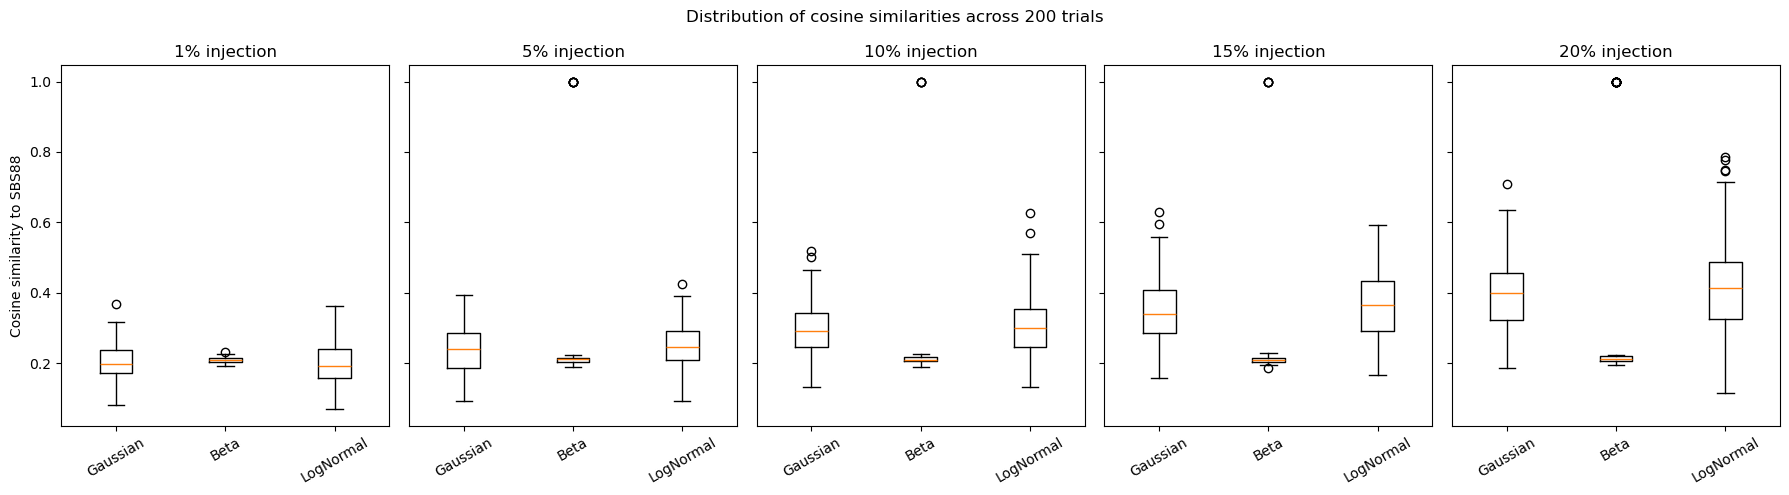

In [23]:
fig, axes = plt.subplots(1, len(injection_levels), figsize=(18, 5), sharey=True)

for i, level in enumerate(injection_levels):
    data  = [cosine_results[d][level] for d in cosine_results]
    axes[i].boxplot(data, tick_labels=list(cosine_results.keys()))
    axes[i].set_title(f"{int(level*100)}% injection")
    axes[i].tick_params(axis="x", rotation=30)
    if i == 0:
        axes[i].set_ylabel("Cosine similarity to SBS88")

plt.suptitle("Distribution of cosine similarities across 200 trials")
plt.tight_layout()
plt.show()

In [24]:
summary_rows = []
for dist in cosine_results:
    for level in injection_levels:
        vals = cosine_results[dist][level]
        summary_rows.append({
            "Distribution": dist,
            "Injection level": f"{int(level*100)}%",
            "Mean cosine": round(np.mean(vals), 4),
            "Std": round(np.std(vals), 4),
            "Min": round(np.min(vals), 4),})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Distribution Injection level  Mean cosine    Std    Min
    Gaussian              1%       0.2023 0.0474 0.0804
    Gaussian              5%       0.2403 0.0658 0.0918
    Gaussian             10%       0.2995 0.0704 0.1338
    Gaussian             15%       0.3509 0.0899 0.1595
    Gaussian             20%       0.3982 0.0952 0.1866
        Beta              1%       0.2101 0.0075 0.1919
        Beta              5%       0.2780 0.2227 0.1898
        Beta             10%       0.2472 0.1672 0.1904
        Beta             15%       0.2526 0.1798 0.1875
        Beta             20%       0.3876 0.3302 0.1954
   LogNormal              1%       0.1995 0.0556 0.0698
   LogNormal              5%       0.2507 0.0589 0.0938
   LogNormal             10%       0.3051 0.0812 0.1338
   LogNormal             15%       0.3677 0.0929 0.1672
   LogNormal             20%       0.4172 0.1258 0.1162


In [25]:
from scipy.optimize import nnls
from scipy.stats import entropy
import random
from numpy.linalg import norm

def kl_divergence(p, q, epsilon=1e-10):
    p = np.array(p, dtype=float) + epsilon
    q = np.array(q, dtype=float) + epsilon
    p = p / p.sum()
    q = q / q.sum()
    return entropy(p, q)

print('kl_divergence function defined.')

kl_divergence function defined.


In [26]:
true_sbs88_vec   = final_df['SBS88_GRCh38'].values
normal_colon_vec = final_df['Normal_colon'].values

cosine_results = {dist: {} for dist in results}
kl_vs_sbs88    = {dist: {} for dist in results}
kl_vs_bg       = {dist: {} for dist in results}

sim_dispatch_kl = {
    'Gaussian':  lambda lv: simulate_gaussian( final_df, 'SBS88_GRCh38', lv, 200, n_muts_median),
    'Beta':      lambda lv: simulate_beta(     final_df, 'SBS88_GRCh38', lv, 200, n_muts_median),
    'LogNormal': lambda lv: simulate_lognormal(final_df, 'SBS88_GRCh38', lv, 200, n_muts_median)}

for dist in results:
    for level in injection_levels:
        spectra = results[dist][level]
        cosine_results[dist][level] = [cosine_similarity(s, true_sbs88_vec) for s in spectra]
        kl_vs_sbs88[dist][level]    = [kl_divergence(s, true_sbs88_vec)    for s in spectra]
        kl_vs_bg[dist][level]       = [kl_divergence(s, normal_colon_vec)  for s in spectra]

print('KL divergences computed.')

KL divergences computed.


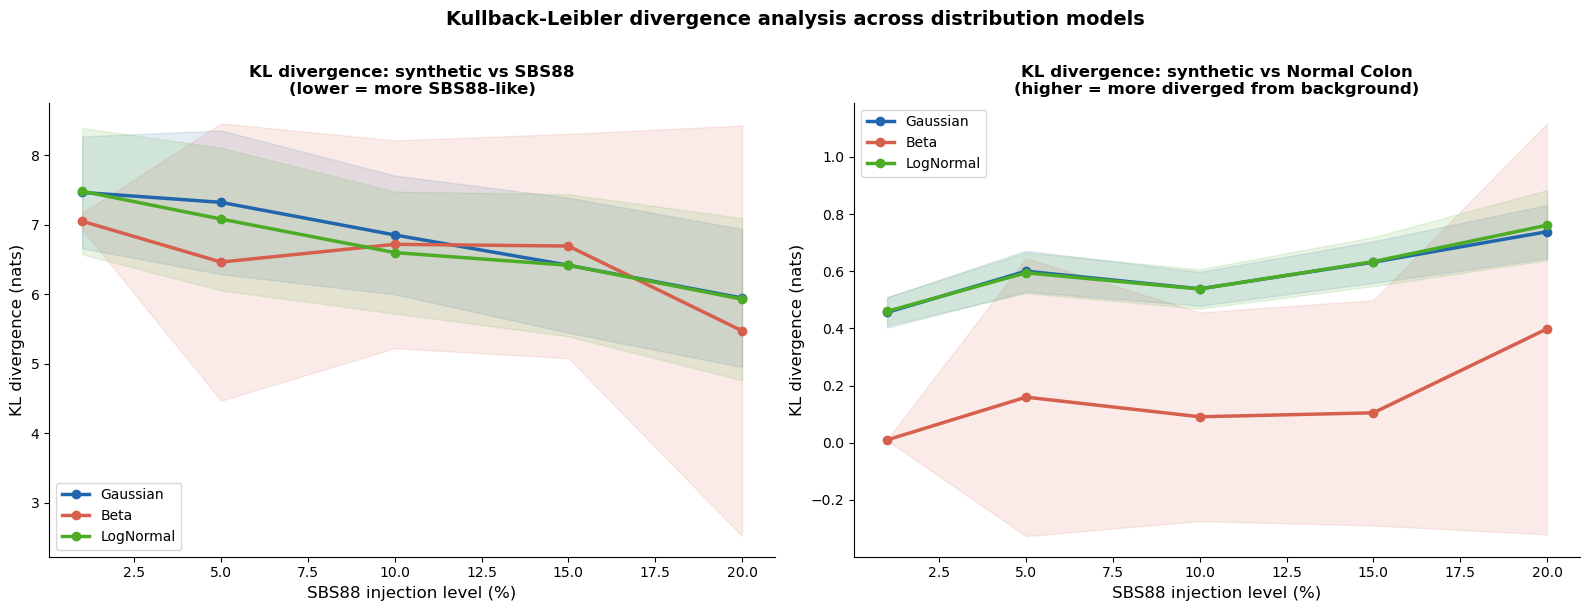

In [27]:
fig, (ax_sbs, ax_bg) = plt.subplots(1, 2, figsize=(16, 6))

for dist in cosine_results:
    pcts  = [l * 100 for l in injection_levels]
    m_sbs = [np.mean(kl_vs_sbs88[dist][l]) for l in injection_levels]
    s_sbs = [np.std( kl_vs_sbs88[dist][l]) for l in injection_levels]
    m_bg  = [np.mean(kl_vs_bg[dist][l])    for l in injection_levels]
    s_bg  = [np.std( kl_vs_bg[dist][l])    for l in injection_levels]

    ax_sbs.plot(pcts, m_sbs, marker='o', linewidth=2.5, label=dist, color=COLOURS[dist])
    ax_sbs.fill_between(pcts, np.array(m_sbs)-np.array(s_sbs),
                              np.array(m_sbs)+np.array(s_sbs), alpha=0.12, color=COLOURS[dist])
    ax_bg.plot(pcts, m_bg, marker='o', linewidth=2.5, label=dist, color=COLOURS[dist])
    ax_bg.fill_between(pcts,  np.array(m_bg)-np.array(s_bg),
                              np.array(m_bg)+np.array(s_bg),  alpha=0.12, color=COLOURS[dist])

ax_sbs.set_xlabel('SBS88 injection level (%)', fontsize=12)
ax_sbs.set_ylabel('KL divergence (nats)', fontsize=12)
ax_sbs.set_title('KL divergence: synthetic vs SBS88\n(lower = more SBS88-like)',
                  fontsize=12, fontweight='bold')
ax_sbs.legend(fontsize=10)
ax_sbs.spines['top'].set_visible(False)
ax_sbs.spines['right'].set_visible(False)

ax_bg.set_xlabel('SBS88 injection level (%)', fontsize=12)
ax_bg.set_ylabel('KL divergence (nats)', fontsize=12)
ax_bg.set_title('KL divergence: synthetic vs Normal Colon\n(higher = more diverged from background)',
                 fontsize=12, fontweight='bold')
ax_bg.legend(fontsize=10)
ax_bg.spines['top'].set_visible(False)
ax_bg.spines['right'].set_visible(False)

plt.suptitle('Kullback-Leibler divergence analysis across distribution models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kl_divergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Alpha Optimisation

### What we are doing

Part 1 told us that at different injection levels, simulated spectra look more or less like SBS88. But it did not tell us: **for a given observed spectrum, what is the level of colibactin exposure (alpha) that best explains it?**

My approach is:

1. For a candidate `mean_a`, draw many alpha values from the distribution (Gaussian / Beta /LogNormal), simulate the resulting spectra, and average them into a single **expected spectrum** E[P(alpha)]
2. Measure how far that expected spectrum is from the observed spectrum using KL divergence
3. Sweep `mean_a` from 0 to 0.5 and find the value that minimises the loss I'm thinking that is the **optimal alpha** for that distribution model
4. Compare the minimum loss across all three distributions to find which one best describes the observed data
5. Use the optimal alpha to compute P(APC c.835-8A>G | alpha)

The observed spectrum here is built from the TCGA data (the mean spectrum across all MSS colorectal tumours), standing in for a real patient cohort.


Build the observed spectrum from TCGA

We need something to optimise against. I am going to use the average simulated spectrum at the paper's reported SBS88 detection threshold (5% injection, Gaussian) as a proxy for a real cohort spectrum. Replacing `observed_spectrum` with the actual 96-channel frequency vector

Observed spectrum sum: 1.0
NOTE: Replace this with real cohort spectrum from TCGA MAF or COSMIC CRC profile.
Current input is Normal_colon - optimiser should return mean_a ~ 0 as a sanity check.


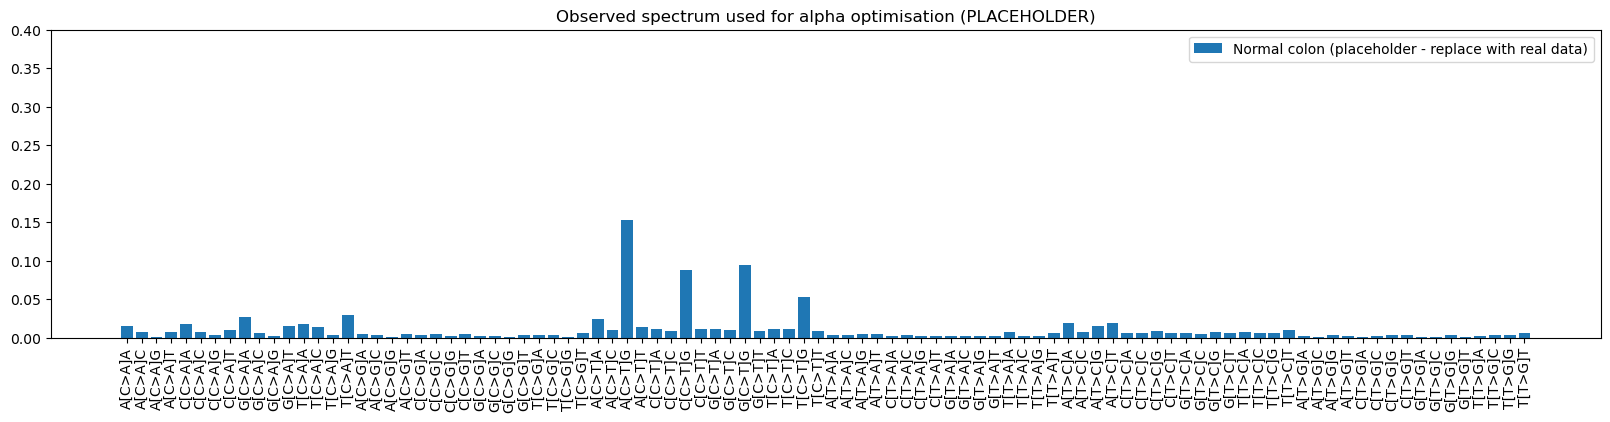

In [46]:
observed_spectrum = final_df['Normal_colon'].values.copy()

print('Observed spectrum sum:', observed_spectrum.sum().round(6))
print('NOTE: Replace this with real cohort spectrum from TCGA MAF or COSMIC CRC profile.')

vis_data([observed_spectrum], final_df['Context'],
         labels=['Normal colon (placeholder - replace with real data)'],
         title='Observed spectrum used for alpha optimisation (PLACEHOLDER)')

Expected spectrum function

For a given distribution and `mean_a`, we draw many alphas, simulate spectra, and average them. This gives E[P(alpha)]  what the model *expects* the average tumour to look like under that exposure level and distribution assumption.

In [47]:
def expected_spectrum(dist_name, mean_a, df, distrib='SBS88_GRCh38',
                      n_samples=200, n_mutations=None):
    '''
    Simulate n_samples spectra from the given distribution at mean_a,then return their average as the expected spectrum E[P(alpha)].

    This is what the model predicts the average tumour spectrum looks like if the population-level colibactin exposure has mean = mean_a and
    follows distribution dist_name.

    Args:
        dist_name : 'Gaussian', 'Beta', or 'LogNormal'
        mean_a: candidate mean alpha (colibactin fraction) in [0, 1]
        df: final_df
        distrib: target signature column
        n_samples: number of spectra to average over (more = smoother loss)
        n_mutations : mutations per spectrum (defaults to TCGA median)

    Returns a 96-element array.
    '''
    if n_mutations is None:
        n_mutations = n_muts_median

    sim_fns = {
        'Gaussian':simulate_gaussian,
        'Beta': simulate_beta,
        'LogNormal': simulate_lognormal,
    }
    if dist_name not in sim_fns:
        raise ValueError(f"dist_name must be one of {list(sim_fns.keys())}")

    spectra = sim_fns[dist_name](df, distrib, mean_a,
                                 n_trials=n_samples, n_mutations=n_mutations)
    return spectra.mean(axis=0)  # average across all simulated tumours

print('expected_spectrum defined.')

expected_spectrum defined.


Loss function over mean_a

The loss measures how far the model's expected spectrum (at a given mean_a and distribution) is from the observed spectrum. We minimise this to find the optimal mean_a.

L(mean_a, dist) = KL( observed_spectrum  ||  E[P(alpha | dist, mean_a)] )


Lower loss = the model at this mean_a under this distribution explains the observeddata better.

In [48]:
def population_loss(mean_a, dist_name, observed_spectrum, df,
                    distrib='SBS88_GRCh38', n_samples=100, n_mutations=None):
    '''
    Loss = KL( observed_spectrum || E[P(alpha)] ) at a given mean_a.

    Args:
        mean_a: candidate mean colibactin fraction in [0, 1]
        dist_name: 'Gaussian', 'Beta', or 'LogNormal'
        observed_spectrum: 96-element frequency vector from real or proxy data
        df: final_df
        distrib: target signature column
        n_samples: spectra to average per evaluation (100 balances speed vs noise)
        n_mutations: mutations per spectrum

    Returns a scalar loss value. Lower = better fit.
    '''
    exp_spec = expected_spectrum(dist_name, mean_a, df, distrib, n_samples, n_mutations)
    return kl_divergence(observed_spectrum, exp_spec)

print('population_loss defined.')

population_loss defined.


Grid search across all three distributions

Sweep `mean_a` from 0 to 0.5 for each distribution and record the loss at every point.
This gives the full loss curve for each distribution
Where the minimum is (the optimal alpha for that distribution) and which distribution achieves the lowest minimum loss (the best-fitting model)

In [49]:
# Grid of mean_a values to evaluate
# Range 0 to 0.5
alpha_grid = np.linspace(0.0, 0.5, 26)

N_SAMPLES_GRID = 100

loss_curves = {} 

for dist_name in ['Gaussian', 'Beta', 'LogNormal']:
    losses = []
    for mean_a in alpha_grid:
        if mean_a == 0.0:
            # At mean_a=0 the log-normal is undefined; use a tiny valu
            mean_a_eval = 1e-4
        else:
            mean_a_eval = mean_a
        loss = population_loss(mean_a_eval, dist_name, observed_spectrum,
                               final_df, n_samples=N_SAMPLES_GRID)
        losses.append(loss)
    loss_curves[dist_name] = np.array(losses)

print('Grid search complete.')

Grid search complete.


Find the optimal alpha per distribution and compare

In [50]:
optimal_results = {}

for dist_name, losses in loss_curves.items():
    best_idx = np.argmin(losses)
    best_alpha = alpha_grid[best_idx]
    best_loss = losses[best_idx]
    optimal_results[dist_name] = {
        'optimal_alpha': best_alpha,
        'min_loss':best_loss}
    print(f'{dist_name:}  optimal mean_a = {best_alpha:.3f}   min KL loss = {best_loss:.5f}')

best_dist = min(optimal_results, key=lambda d: optimal_results[d]['min_loss'])
print(f'\nBest-fitting distribution: {best_dist}')
print(f'Optimal alpha (mean colibactin fraction): {optimal_results[best_dist]["optimal_alpha"]:.3f}')

Gaussian  optimal mean_a = 0.000   min KL loss = 0.00456
Beta  optimal mean_a = 0.000   min KL loss = 0.00387
LogNormal  optimal mean_a = 0.020   min KL loss = 0.00552

Best-fitting distribution: Beta
Optimal alpha (mean colibactin fraction): 0.000


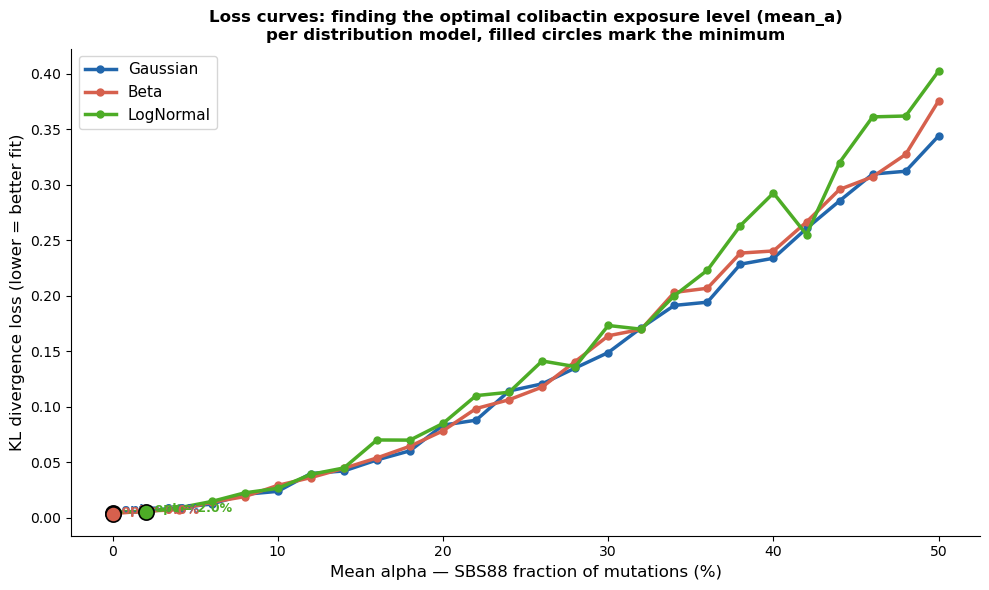

In [51]:
# Plot the loss curves for all three distributions on one axis
fig, ax = plt.subplots(figsize=(10, 6))

for dist_name, losses in loss_curves.items():
    ax.plot(alpha_grid * 100, losses, marker='o', linewidth=2.5, markersize=5,
            label=dist_name, color=COLOURS[dist_name])
    # Mark the minimum
    opt_a = optimal_results[dist_name]['optimal_alpha']
    opt_l = optimal_results[dist_name]['min_loss']
    ax.scatter([opt_a * 100], [opt_l], color=COLOURS[dist_name],
               s=120, zorder=5, edgecolors='black', linewidths=1.2)
    ax.annotate(f"  opt = {opt_a*100:.1f}%",
                xy=(opt_a * 100, opt_l), fontsize=9,
                color=COLOURS[dist_name], fontweight='bold')

ax.set_xlabel('Mean alpha — SBS88 fraction of mutations (%)', fontsize=12)
ax.set_ylabel('KL divergence loss (lower = better fit)', fontsize=12)
ax.set_title('Loss curves: finding the optimal colibactin exposure level (mean_a)\n'
             'per distribution model, filled circles mark the minimum',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('alpha_optimisation_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

What the optimal alpha looks like in spectrum space

Plot the observed spectrum alongside the expected spectrum at the optimal alpha for each distribution. Visually confirms the fit.

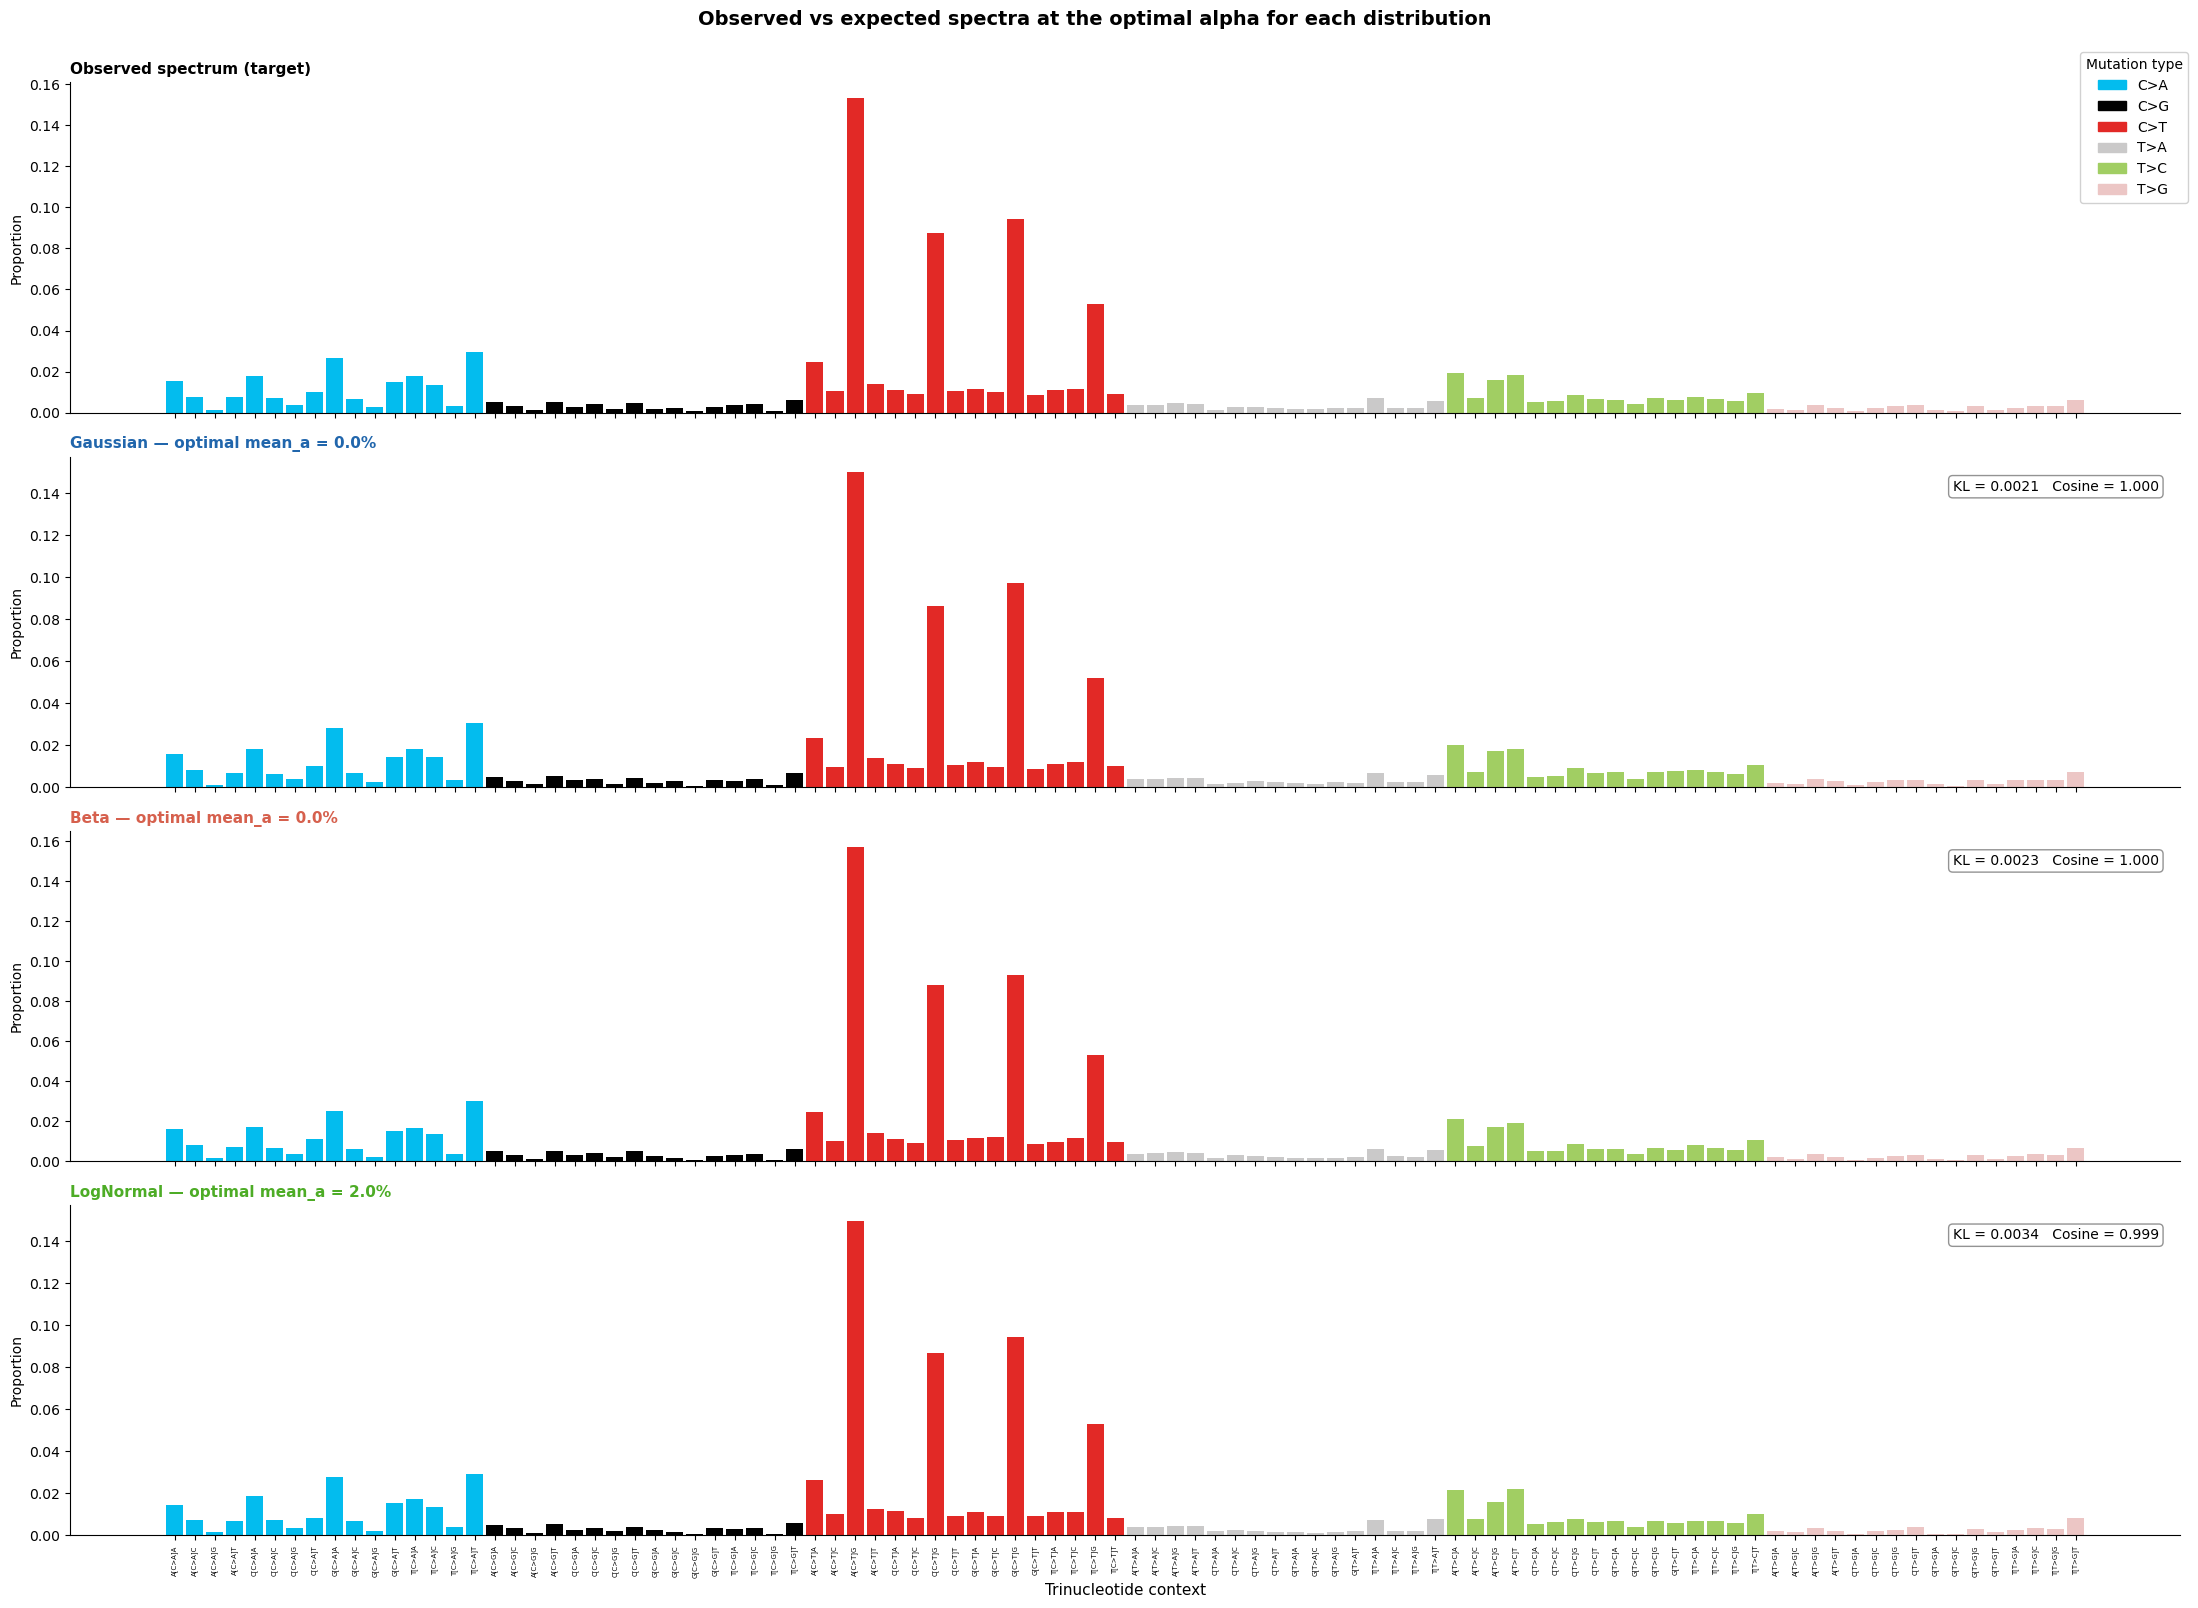

In [52]:
fig, axes = plt.subplots(4, 1, figsize=(22, 16), sharex=True)

# Row 0: observed spectrum
axes[0].bar(range(96), observed_spectrum, color=colours, width=0.85, linewidth=0)
axes[0].set_title('Observed spectrum (target)', fontsize=11, fontweight='bold', loc='left')
axes[0].set_ylabel('Proportion', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

#rest of rows are the other distributions
for i, dist_name in enumerate(['Gaussian', 'Beta', 'LogNormal']):
    opt_a = optimal_results[dist_name]['optimal_alpha']
    # Use a tiny floor for log-normal when opt_a rounds to 0
    opt_a_eval = max(opt_a, 1e-4)
    exp_spec = expected_spectrum(dist_name, opt_a_eval, final_df, n_samples=200)

    kl  = kl_divergence(observed_spectrum, exp_spec)
    cos = cosine_similarity(observed_spectrum, exp_spec)

    ax = axes[i + 1]
    ax.bar(range(96), exp_spec, color=colours, width=0.85, linewidth=0)
    ax.set_title(
        f'{dist_name} — optimal mean_a = {opt_a*100:.1f}%',
        fontsize=11, fontweight='bold', loc='left', color=COLOURS[dist_name])
    ax.set_ylabel('Proportion', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.99, 0.93,
            f'KL = {kl:.4f}   Cosine = {cos:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.85))

axes[-1].set_xticks(range(96))
axes[-1].set_xticklabels(contexts, rotation=90, fontsize=5)
axes[-1].set_xlabel('Trinucleotide context', fontsize=11)

legend_handles = [mpatches.Patch(color=c, label=t) for t, c in MUT_TYPE_COLOURS.items()]
fig.legend(handles=legend_handles, title='Mutation type',
           loc='upper right', bbox_to_anchor=(1.0, 0.98), fontsize=10, framealpha=0.9)
fig.suptitle('Observed vs expected spectra at the optimal alpha for each distribution',
             fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('optimal_alpha_spectrum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Summary table of optimal alpha per distribution

In [53]:

summary_opt = []
for dist_name in ['Gaussian', 'Beta', 'LogNormal']:
    opt_a = optimal_results[dist_name]['optimal_alpha']
    opt_a_eval = max(opt_a, 1e-4)
    exp_spec = expected_spectrum(dist_name, opt_a_eval, final_df, n_samples=200)
    kl = kl_divergence(observed_spectrum, exp_spec)
    cos = cosine_similarity(observed_spectrum, exp_spec)
    summary_opt.append({
        'Distribution': dist_name,
        'Optimal mean_a': round(opt_a, 4),
        'Optimal mean_a (%)': f"{opt_a*100:.1f}%",
        'KL divergence': round(kl, 5),
        'Cosine similarity': round(cos, 4),
        'Best fit': 'YES' if dist_name == best_dist else ''})

summary_opt_df = pd.DataFrame(summary_opt)
print(summary_opt_df.to_string(index=False))

Distribution  Optimal mean_a Optimal mean_a (%)  KL divergence  Cosine similarity Best fit
    Gaussian            0.00               0.0%        0.00223             0.9997         
        Beta            0.00               0.0%        0.00225             0.9996      YES
   LogNormal            0.02               2.0%        0.00415             0.9990         
